## 📦 Step 1: Importing Required Libraries

We begin by importing all the essential Python libraries used for data handling, visualization, clustering algorithms, and evaluation metrics.

- **NumPy, Pandas**: For numerical operations and data manipulation.
- **Matplotlib, Seaborn**: For creating insightful visualizations.
- **Sklearn & Scipy**: For implementing clustering models (KMeans, Agglomerative, DBSCAN), dendrograms, and evaluating model performance using Silhouette Score and Davies-Bouldin Score.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from collections import Counter
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score, davies_bouldin_score

## ⬇️ Step 2: Downloading the Dataset

We use `kagglehub` to download the "Mall Customer Segmentation" dataset from Kaggle. This dataset contains data about customers, including:
- Gender
- Age
- Annual Income (in $1000)
- Spending Score (1–100)

This dataset is ideal for unsupervised clustering analysis using algorithms like KMeans, Agglomerative Clustering, and DBSCAN.

In [2]:
import kagglehub

# Download the latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

100%|██████████| 1.55k/1.55k [00:00<00:00, 2.82MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/versions/1


## 📁 Step 3: Organizing Dataset Files

Once downloaded, we move the dataset to a cleaner and more accessible folder named `/content/Dataset` so that we can easily load it later.

In [3]:
! mv /root/.cache/kagglehub/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/versions/1/* /content/Dataset

## 📊 Step 4: Loading the Dataset

Let’s read the CSV file into a Pandas DataFrame and take a quick look at the first few entries. This gives us an idea of what features are available in the dataset and how the data is structured.

In [4]:
df = pd.read_csv('/content/Dataset/Mall_Customers.csv')
print(f"Dataset Shape: {df.shape}")
df.head(5)

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 👨‍🦰👩 Step 5: Gender Distribution of Customers

Let’s visualize the gender distribution in our dataset using a pie chart. This will help us understand the proportion of male and female customers.

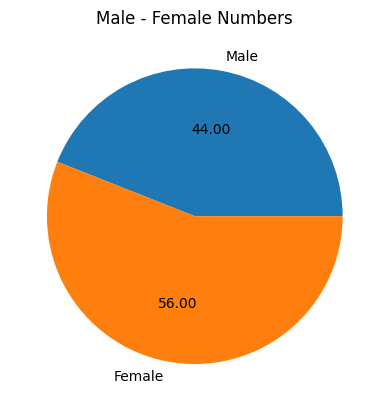

In [5]:
cnt = Counter(df['Gender'])
plt.pie([cnt['Male'], cnt['Female']], labels=['Male', 'Female'], autopct='%.2f')
plt.title("Male - Female Numbers")
plt.show()

## 💸 Step 6: Spending Score vs Annual Income

This scatter plot helps us observe whether there's any visible clustering pattern in how much people spend versus how much they earn. These patterns are useful for validating the clustering algorithms later.

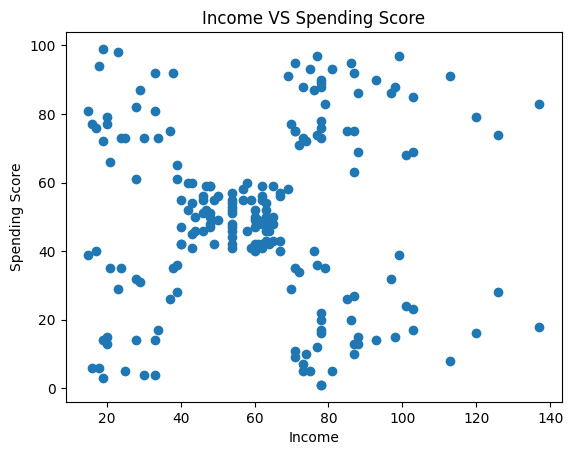

In [6]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.title("Income VS Spending Score")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

## 👴🧒 Step 7: Age vs Spending Score

This scatter plot shows how customers' spending habits relate to their age. It helps in identifying whether younger or older customers spend more on average.

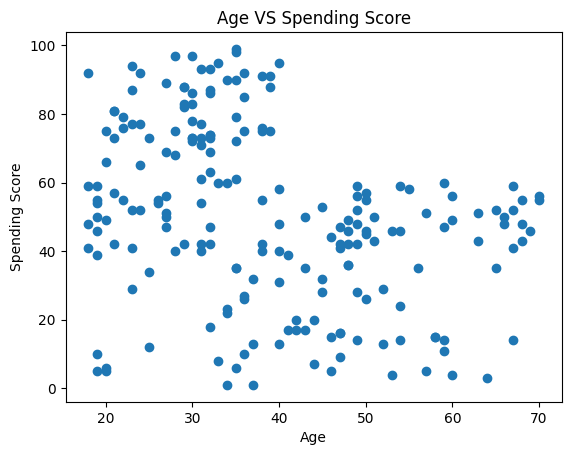

In [7]:
plt.scatter(df['Age'], df['Spending Score (1-100)'])
plt.title("Age VS Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

## 💼 Step 8: Age vs Annual Income

This plot helps visualize how customers’ annual income varies with age. It may reveal clusters like high-income young professionals or older high-income customers.

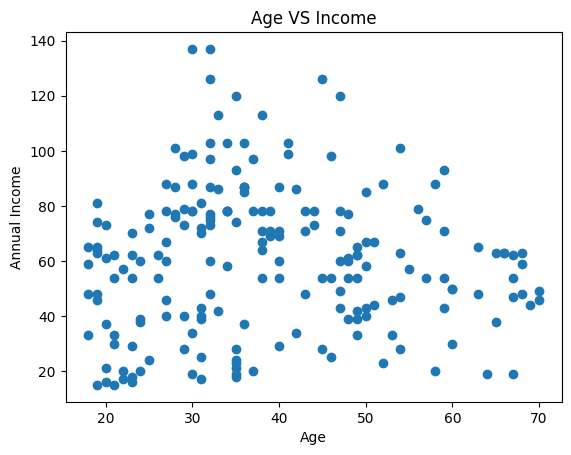

In [8]:
plt.scatter(df['Age'], df['Annual Income (k$)'])
plt.title("Age VS Income")
plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.show()

## 📊 Step 9: Age Distribution

Let’s visualize the age distribution of all customers using a countplot. This shows which age groups are more dominant in our dataset.

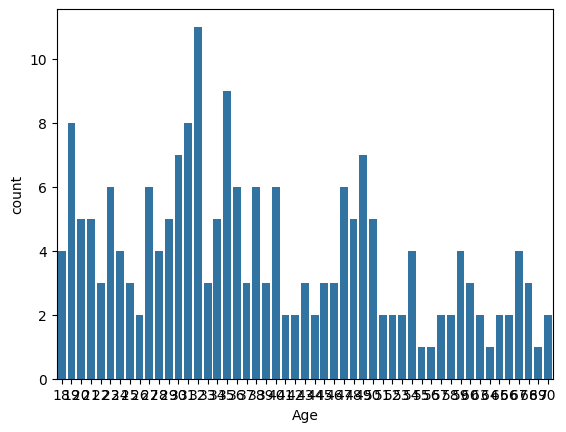

In [9]:
sns.countplot(df, x='Age')
plt.show()

## 📈 Step 10: KMeans – Finding the Optimal Number of Clusters (Elbow Method)

We apply the **Elbow Method** on two features – `Annual Income` and `Spending Score` – to find the optimal number of clusters for KMeans.

- **WCSS (Within-Cluster Sum of Squares)** is calculated for different values of `k` (1 to 15).
- A sharp bend or "elbow" in the plot indicates the ideal number of clusters.

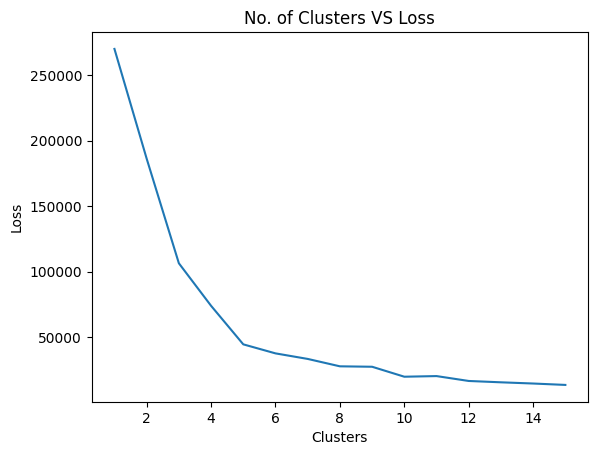

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df.iloc[:, [3, 4]]  # Annual Income and Spending Score

wcss = []

for i in range(1, 16):
  km = KMeans(n_clusters=i)
  km.fit(X)
  wcss.append(km.inertia_)

sns.lineplot(x=list(range(1, 16)), y=wcss)
plt.xlabel("Clusters")
plt.ylabel("Loss")
plt.title("No. of Clusters VS Loss")
plt.show()

## 🧠 Step 11: KMeans Clustering (k=5)

Based on the elbow method, we select `k=5` clusters and apply the KMeans algorithm. Each cluster is visualized using a different color.

We also display the cluster centroids in black.

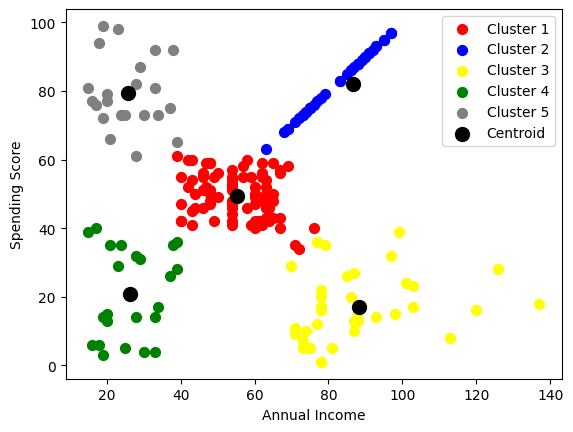

In [11]:
km = KMeans(n_clusters=5, random_state=0)

pred = km.fit_predict(X)
clusters = km.cluster_centers_

plt.scatter(X[pred == 0].iloc[:, 0], X[pred == 0].iloc[:, 1], c='red', s=50, label='Cluster 1')
plt.scatter(X[pred == 1].iloc[:, 1], X[pred == 1].iloc[:, 1], c='blue', s=50, label='Cluster 2')
plt.scatter(X[pred == 2].iloc[:, 0], X[pred == 2].iloc[:, 1], c='yellow', s=50, label='Cluster 3')
plt.scatter(X[pred == 3].iloc[:, 0], X[pred == 3].iloc[:, 1], c='green', s=50, label='Cluster 4')
plt.scatter(X[pred == 4].iloc[:, 0], X[pred == 4].iloc[:, 1], c='grey', s=50, label='Cluster 5')

plt.scatter(clusters[:, 0], clusters[:, 1], c='black', s=100, label='Centroid')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

## 📏 Step 12: Evaluating KMeans Clustering

We evaluate the clustering result using two standard metrics:

- **Silhouette Score**: Measures how similar a point is to its own cluster vs other clusters. Ranges from -1 to 1 (higher is better).
- **Davies-Bouldin Score**: Lower values indicate better clustering performance.

In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f"Silhouette Score: {silhouette_score(X, pred)}")
print(f'Davies-Bouldin Score: {davies_bouldin_score(X, pred)}')

Silhouette Score: 0.553931997444648
Davies-Bouldin Score: 0.5725628995597083


## 🌿 Step 13: Dendrogram – Hierarchical Clustering Visualization

We use a **Dendrogram** to visualize the hierarchical clustering process using the **Ward linkage method**. This helps determine the number of clusters by cutting the tree at the longest vertical line that doesn’t cross another link.

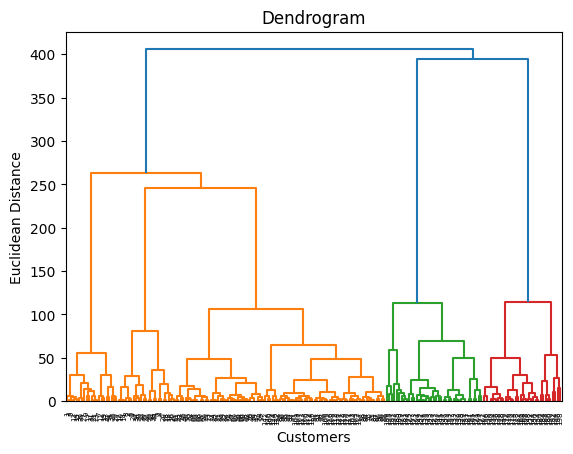

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram

dendrogram(linkage(X, metric='euclidean', method='ward'))
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.title("Dendrogram")
plt.show()

## 🧩 Step 14: Hierarchical Clustering (Agglomerative)

We apply **Agglomerative Clustering** using 5 clusters. The `NearestCentroid` classifier is used to approximate the centroids for visualization.

Each cluster is displayed in a different color along with black centroids.

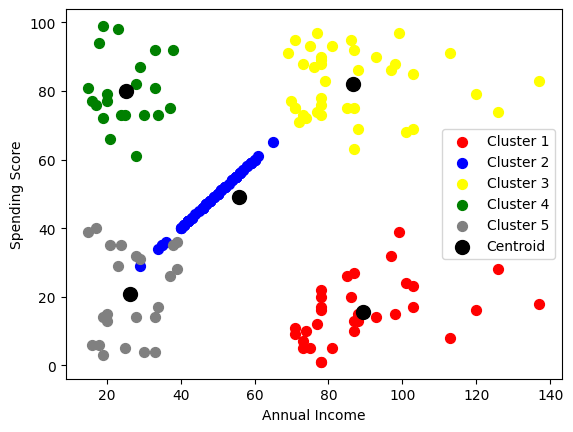

In [14]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestCentroid

agg = AgglomerativeClustering(n_clusters=5)
pred = agg.fit_predict(X)

clf = NearestCentroid()
clf.fit(X, pred)

clusters = clf.centroids_

plt.scatter(X[pred == 0].iloc[:, 0], X[pred == 0].iloc[:, 1], c='red', s=50, label='Cluster 1')
plt.scatter(X[pred == 1].iloc[:, 1], X[pred == 1].iloc[:, 1], c='blue', s=50, label='Cluster 2')
plt.scatter(X[pred == 2].iloc[:, 0], X[pred == 2].iloc[:, 1], c='yellow', s=50, label='Cluster 3')
plt.scatter(X[pred == 3].iloc[:, 0], X[pred == 3].iloc[:, 1], c='green', s=50, label='Cluster 4')
plt.scatter(X[pred == 4].iloc[:, 0], X[pred == 4].iloc[:, 1], c='grey', s=50, label='Cluster 5')

plt.scatter(clusters[:, 0], clusters[:, 1], c='black', s=100, label='Centroid')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

## 🧩 Step 15: Cluster Evaluation – Silhouette & Davies-Bouldin Score

We evaluate the clustering performance using two metrics:

- **Silhouette Score** → higher is better (range: -1 to 1)
- **Davies-Bouldin Score** → lower is better

These metrics help us understand how well-defined our clusters are.

In [15]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f"Silhouette Score: {silhouette_score(X, pred)}")
print(f'Davies-Bouldin Score: {davies_bouldin_score(X, pred)}')

Silhouette Score: 0.5529945955148897
Davies-Bouldin Score: 0.5782207452369454


## 🧩 Step 16: Finding Optimal `eps` for DBSCAN using k-distance Graph

To choose a suitable `eps` value for DBSCAN, we plot the distance to the **5th nearest neighbor** for all points.  
Look for the **"elbow" point** in the graph, where the slope increases rapidly. That value can be a good choice for `eps`.

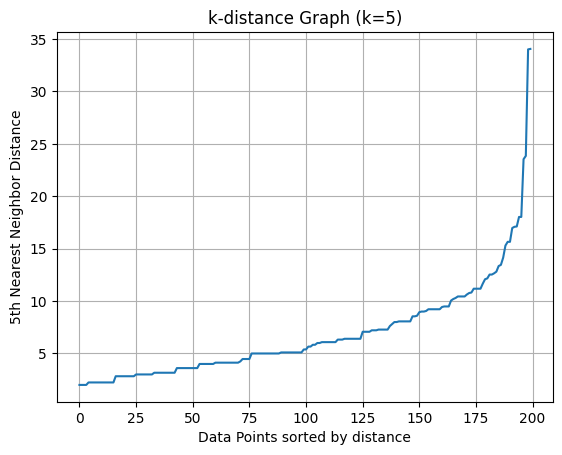

In [16]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

nearest_nei = NearestNeighbors(n_neighbors=5)
nearest_nei.fit(X)

knn, _ = nearest_nei.kneighbors(X)
sorted_knn = np.sort(knn[:, -1])

plt.plot(sorted_knn)
plt.title("k-distance Graph (k=5)")
plt.xlabel("Data Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid()
plt.show()

## 🧩 Step 17: DBSCAN Clustering & Visualization

We now apply **DBSCAN** using chosen `eps=9` and `min_samples=5`.  
It clusters dense regions and labels outliers (noise) as `-1`.

Each cluster is displayed with a unique color, and noise points are shown in **black**.

5


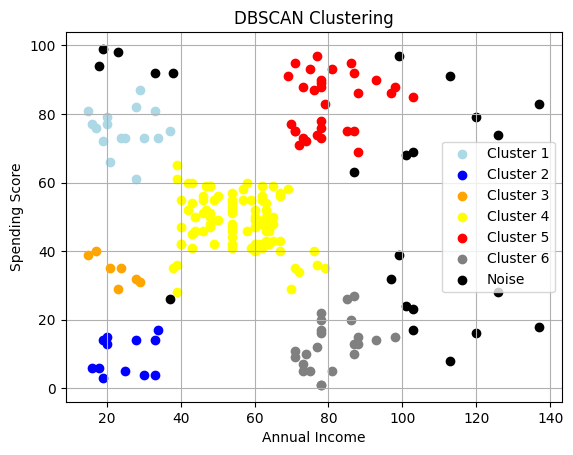

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

sc = StandardScaler()

dbs = DBSCAN(eps=9, min_samples=5)
pred = dbs.fit_predict(X)

print(max(pred))

plt.scatter(X[pred == 0].iloc[:, 0], X[pred == 0].iloc[:, 1], label='Cluster 1', c='lightblue')
plt.scatter(X[pred == 1].iloc[:, 0], X[pred == 1].iloc[:, 1], label='Cluster 2', c='blue')
plt.scatter(X[pred == 2].iloc[:, 0], X[pred == 2].iloc[:, 1], label='Cluster 3', c='orange')
plt.scatter(X[pred == 3].iloc[:, 0], X[pred == 3].iloc[:, 1], label='Cluster 4', c='yellow')
plt.scatter(X[pred == 4].iloc[:, 0], X[pred == 4].iloc[:, 1], label='Cluster 5', c='red')
plt.scatter(X[pred == 5].iloc[:, 0], X[pred == 5].iloc[:, 1], label='Cluster 6', c='grey')
# plt.scatter(X[pred == 6].iloc[:, 0], X[pred == 6].iloc[:, 1], label='Cluster 7', c='green')
plt.scatter(X[pred == -1].iloc[:, 0], X[pred == -1].iloc[:, 1], label='Noise', c='black')

plt.legend()
plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid()
plt.show()

## 🧩 Step 18: DBSCAN – Cluster Evaluation (Ignoring Noise)

We calculate **Silhouette Score** and **Davies-Bouldin Score**, excluding outliers (`pred == -1`).

This gives a more accurate representation of how well-defined the actual clusters are.

In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f'Silhouette Score: {silhouette_score(X[pred != -1], pred[pred != -1])}')
print(f'Davies-Bouldin Score: {davies_bouldin_score(X[pred != -1], pred[pred != -1])}')

Silhouette Score: 0.5566604765138499
Davies-Bouldin Score: 0.5133566429744099


## 🧪 Step 19: OPTICS Clustering and Cluster Centers

We apply **OPTICS**, a density-based clustering algorithm.  
After clustering, we use `NearestCentroid` to estimate cluster centers (excluding noise: `pred == -1`).  
Finally, we plot the clusters with distinct colors, black centers, and outliers in black.

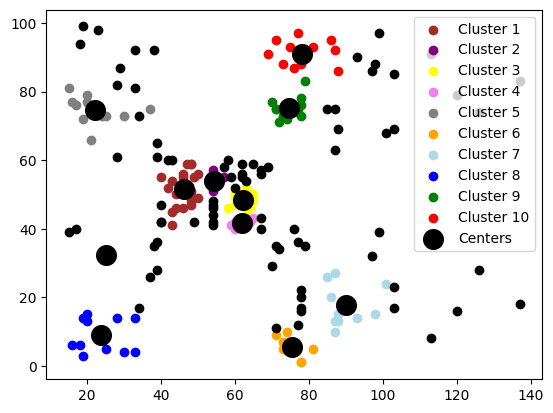

In [19]:
from sklearn.cluster import OPTICS

opt = OPTICS(metric='euclidean')
pred = opt.fit_predict(X)

nc = NearestCentroid()
nc.fit(X[pred != -1], pred[pred != -1])

cents = nc.centroids_

colors = ['red', 'green', 'blue', 'lightblue', 'orange', 'grey', 'violet', 'yellow', 'purple', 'brown']
for i in range(1, max(pred) + 1):
  plt.scatter(X[pred == i].iloc[:, 0], X[pred == i].iloc[:, 1], c=colors.pop(), label=f'Cluster {i}')

plt.scatter(cents[:, 0], cents[:, 1], c='black', label='Centers', s=200)
plt.scatter(X[pred == -1].iloc[:, 0], X[pred == -1].iloc[:, 1], c='black')
plt.legend()
plt.show()

## 📉 Step 20: KMeans – Finding Optimal Number of Clusters

We use the **Elbow Method** to determine the optimal number of clusters by plotting WCSS (Within Cluster Sum of Squares) for `k = 1 to 15`.

This helps identify the "elbow point" where adding more clusters doesn’t significantly reduce WCSS.

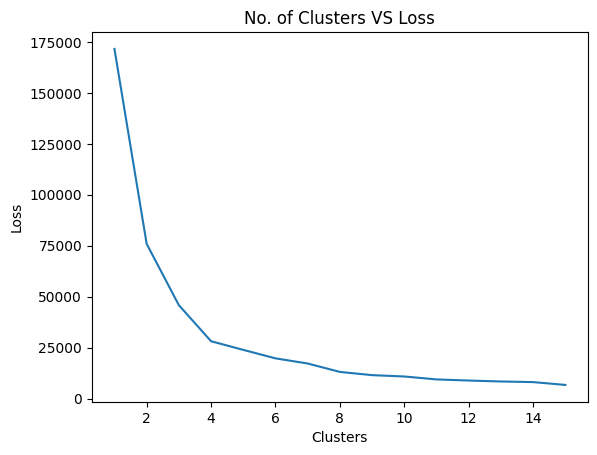

In [20]:
X = df.iloc[:, [2, 4]]

wcss = []

for i in range(1, 16):
  km = KMeans(n_clusters=i)
  km.fit(X)
  wcss.append(km.inertia_)

sns.lineplot(x=list(range(1, 16)), y=wcss)
plt.xlabel("Clusters")
plt.ylabel("Loss")
plt.title("No. of Clusters VS Loss")
plt.show()

## 🎯 Step 21: KMeans Clustering and Visualization

We run **KMeans with `n_clusters = 3`**, and visualize the resulting clusters with their centroids.  
Each cluster is plotted with a unique color, and centroids are highlighted in **black**.

> ⚠️ Note: Make sure to match `.iloc[:, 0]` and `.iloc[:, 1]` properly for the axis in all clusters.

2


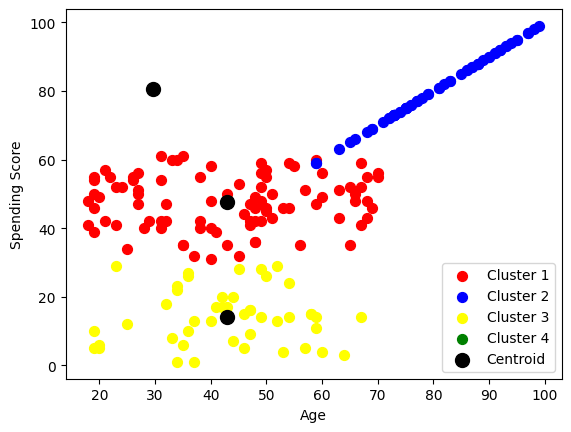

In [22]:
# Clusters: 3
km = KMeans(n_clusters=3, random_state=0)

pred = km.fit_predict(X)

clusters = km.cluster_centers_
print(max(pred))

plt.scatter(X[pred == 0].iloc[:, 0], X[pred == 0].iloc[:, 1], c='red', s=50, label='Cluster 1')
plt.scatter(X[pred == 1].iloc[:, 1], X[pred == 1].iloc[:, 1], c='blue', s=50, label='Cluster 2')
plt.scatter(X[pred == 2].iloc[:, 0], X[pred == 2].iloc[:, 1], c='yellow', s=50, label='Cluster 3')
plt.scatter(X[pred == 3].iloc[:, 0], X[pred == 3].iloc[:, 1], c='green', s=50, label='Cluster 4')
plt.scatter(clusters[:, 0], clusters[:, 1], c='black', s=100, label='Centroid')
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

## 📊 Step 22: Cluster Evaluation – Silhouette & Davies-Bouldin Scores

To evaluate the quality of clustering, we use:
- **Silhouette Score**: Measures how well samples are clustered with other similar samples.
- **Davies-Bouldin Score**: Measures intra-cluster similarity and inter-cluster differences (lower is better).

In [23]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f"Silhouette Score: {silhouette_score(X, pred)}")
print(f'Davies-Bouldin Score: {davies_bouldin_score(X, pred)}')

Silhouette Score: 0.4537025770427172
Davies-Bouldin Score: 0.8238714919085539


## 🌲 Step 23: Dendrogram using Hierarchical Clustering

Before applying hierarchical clustering, we visualize a **dendrogram** to help determine the number of clusters.  
We use `linkage` with **Euclidean distance** and the **Ward method**.

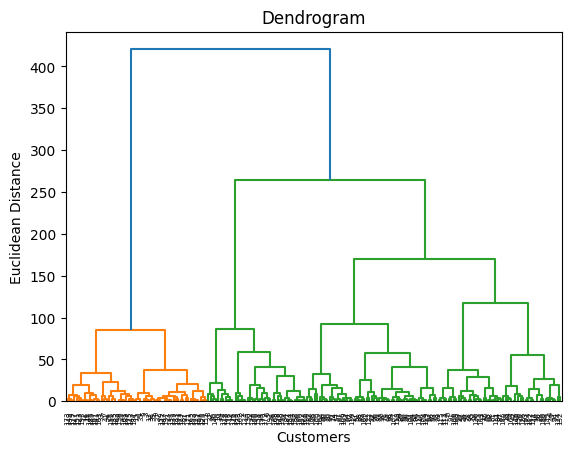

In [24]:
from scipy.cluster.hierarchy import linkage, dendrogram

dendrogram(linkage(X, metric='euclidean', method='ward'))
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.title("Dendrogram")
plt.show()

## 🧬 Step 24: Hierarchical Clustering (Agglomerative)

We apply **Agglomerative Clustering with `n_clusters = 5`**, and use `NearestCentroid` to find cluster centers.  
Clusters are plotted with different colors and the centroids in **black**.

> ⚠️ Ensure axes match correctly for `.iloc` indexing.

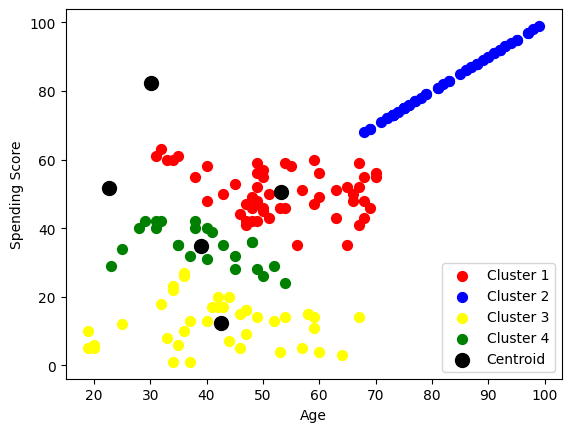

In [25]:
# Using Hierarchal Clustering (Agglomerative)

from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestCentroid

agg = AgglomerativeClustering(n_clusters=5)

pred = agg.fit_predict(X)

clf = NearestCentroid()
clf.fit(X, pred)

clusters = clf.centroids_

plt.scatter(X[pred == 0].iloc[:, 0], X[pred == 0].iloc[:, 1], c='red', s=50, label='Cluster 1')
plt.scatter(X[pred == 1].iloc[:, 1], X[pred == 1].iloc[:, 1], c='blue', s=50, label='Cluster 2')
plt.scatter(X[pred == 2].iloc[:, 0], X[pred == 2].iloc[:, 1], c='yellow', s=50, label='Cluster 3')
plt.scatter(X[pred == 3].iloc[:, 0], X[pred == 3].iloc[:, 1], c='green', s=50, label='Cluster 4')
plt.scatter(clusters[:, 0], clusters[:, 1], c='black', s=100, label='Centroid')
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

## 📊 Step 25: Cluster Evaluation After Hierarchical Clustering

We again evaluate the clustering quality using:
- **Silhouette Score**
- **Davies-Bouldin Score**

This helps determine how well-defined the agglomerative clusters are.

In [26]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f"Silhouette Score: {silhouette_score(X, pred)}")
print(f'Davies-Bouldin Score: {davies_bouldin_score(X, pred)}')

Silhouette Score: 0.40374071753059787
Davies-Bouldin Score: 0.828523468576287


## 📌 Step 26: Plot K-Distance Graph for DBSCAN

- Use `NearestNeighbors` to find the distance to the 5th nearest neighbor.
- Sort and plot these distances to identify the "elbow" point.
- This helps determine a good value for `eps` in DBSCAN.

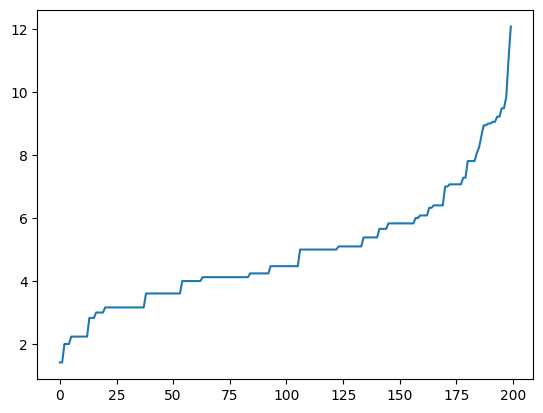

In [27]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

nearest_nei = NearestNeighbors(n_neighbors=5)
nearest_nei.fit(X)
knn, _ = nearest_nei.kneighbors(X)

sorted_knn = np.sort(knn[:, -1])

plt.plot(sorted_knn)
plt.show()

### 📌 **Step 27: Apply DBSCAN and Visualize Clusters**

- DBSCAN is applied with `eps=5.85` and `min_samples=5`.
- `NearestCentroid` is used to estimate centroids (not native to DBSCAN).
- Outliers (`pred == -1`) are shown in black.
- Each cluster is visualized with a different color.

4


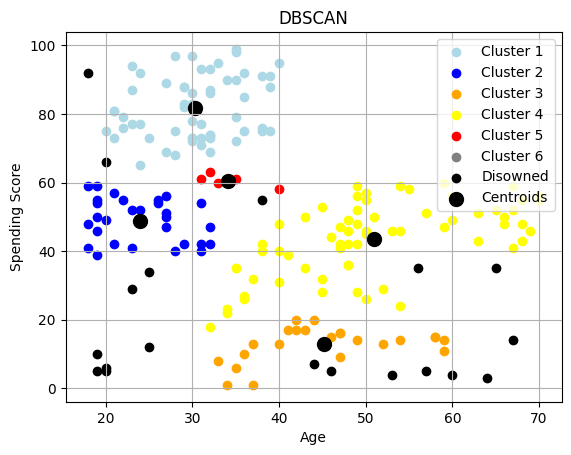

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

dbs = DBSCAN(eps=5.85, min_samples=5)

pred = dbs.fit_predict(X)

nc = NearestCentroid()
nc.fit(X[pred != -1], pred[pred != -1])

cents = nc.centroids_

print(max(pred))
plt.scatter(X[pred == 0].iloc[:, 0], X[pred == 0].iloc[:, 1], label='Cluster 1', c='lightblue')
plt.scatter(X[pred == 1].iloc[:, 0], X[pred == 1].iloc[:, 1], label='Cluster 2', c='blue')
plt.scatter(X[pred == 2].iloc[:, 0], X[pred == 2].iloc[:, 1], label='Cluster 3', c='orange')
plt.scatter(X[pred == 3].iloc[:, 0], X[pred == 3].iloc[:, 1], label='Cluster 4', c='yellow')
plt.scatter(X[pred == 4].iloc[:, 0], X[pred == 4].iloc[:, 1], label='Cluster 5', c='red')
plt.scatter(X[pred == 5].iloc[:, 0], X[pred == 5].iloc[:, 1], label='Cluster 6', c='grey')
# plt.scatter(X[pred == 6].iloc[:, 0], X[pred == 6].iloc[:, 1], label='Cluster 7', c='green')
plt.scatter(X[pred == -1].iloc[:, 0], X[pred == -1].iloc[:, 1], label='Disowned', c='black')
plt.scatter(cents[:, 0], cents[:, 1], label='Centroids', c='black', s=100)
plt.legend()
plt.title("DBSCAN")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.grid()
plt.show()

## 📌 Step 28: Evaluate DBSCAN Clustering Performance

- Evaluate only the core (non-outlier) points.
- **Silhouette Score**: Higher is better (max = 1).
- **Davies-Bouldin Score**: Lower is better (min = 0).

In [29]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f"Silhouette Score: {silhouette_score(X[pred != -1], pred[pred != -1])}")
print(f'Davies-Bouldin Score: {davies_bouldin_score(X[pred != -1], pred[pred != -1])}')

Silhouette Score: 0.32561166761196725
Davies-Bouldin Score: 0.68551195978109


## 📌 Step 29: Determine Optimal Number of Clusters for KMeans

- Use the **Elbow Method** to plot `WCSS` (within-cluster sum of squares) vs number of clusters.
- Helps decide how many clusters to use for KMeans.

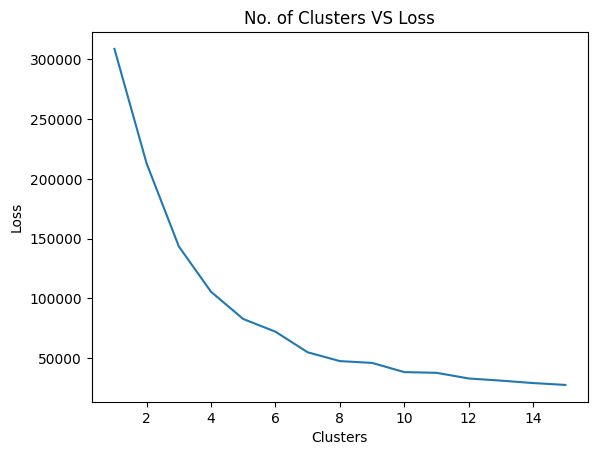

In [30]:
X = df.iloc[:, [2, 3, 4]]

wcss = []

for i in range(1, 16):
  km = KMeans(n_clusters=i)
  km.fit(X)
  wcss.append(km.inertia_)

sns.lineplot(x=list(range(1, 16)), y=wcss)
plt.xlabel("Clusters")
plt.ylabel("Loss")
plt.title("No. of Clusters VS Loss")
plt.show()

## 📌 Step 30: Visualize Clustering in 3D

- Use `matplotlib`'s `3D` plotting to visualize the dataset with 3 features.


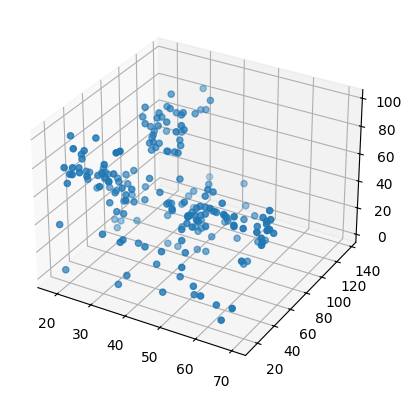

In [31]:
from mpl_toolkits import mplot3d

ax = plt.axes(projection='3d')
ax.scatter3D(X.iloc[:, 0], X.iloc[:, 1], X.iloc[:, 2])

## 📌 Step 31: Apply KMeans with 6 Clusters

- Apply KMeans assuming 6 clusters based on elbow method.
- `random_state=0` ensures reproducibility.

In [32]:
# Clusters: 6
km = KMeans(n_clusters=6, random_state=0)

pred = km.fit_predict(X)

# clusters = km.cluster_centers_
print(max(pred))

5


## 📌 Step 32: Evaluate KMeans Clustering

- Evaluate KMeans predictions using Silhouette and Davies-Bouldin scores.
- Both scores apply to all points (since KMeans assigns every point to a cluster).

In [33]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f"Silhouette Score: {silhouette_score(X, pred)}")
print(f'Davies-Bouldin Score: {davies_bouldin_score(X, pred)}')

Silhouette Score: 0.45095124469943243
Davies-Bouldin Score: 0.7515325100425702


## 📌 Step 33. Dendrogram for Agglomerative Clustering

- Uses `scipy`'s `linkage` method with Ward's method and Euclidean distance.
- Dendrogram helps visualize the hierarchy and decide number of clusters.

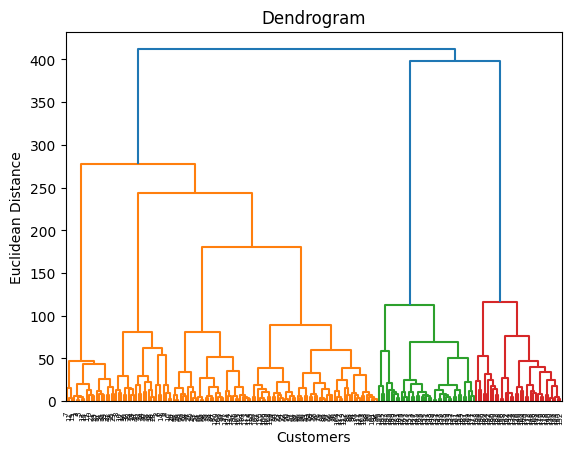

In [34]:
from scipy.cluster.hierarchy import linkage, dendrogram

dendrogram(linkage(X, metric='euclidean', method='ward'))
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.title("Dendrogram")
plt.show()

## 📌 Step 34. Apply Agglomerative Clustering

- Perform hierarchical clustering using 6 clusters.

In [35]:
agg = AgglomerativeClustering(n_clusters=6)

pred = agg.fit_predict(X)
print(max(pred))

5


## 📌 Step 35. Evaluate Agglomerative Clustering

- Use **Silhouette Score** and **Davies-Bouldin Score** for performance.

In [36]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f"Silhouette Score: {silhouette_score(X, pred)}")
print(f'Davies-Bouldin Score: {davies_bouldin_score(X, pred)}')

Silhouette Score: 0.44308912983504156
Davies-Bouldin Score: 0.7684782366478475


## 📌 Step 36. Find Optimal eps using K-Distance Graph

- Use `NearestNeighbors` to compute distances to the 6th nearest neighbor.
- Plot to find the "elbow" for `eps` in DBSCAN.

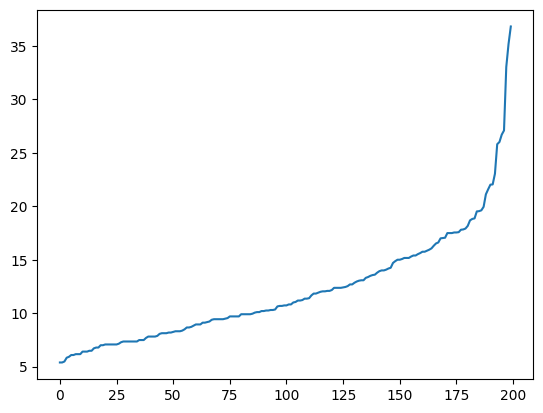

In [37]:
nearest_nei = NearestNeighbors(n_neighbors=6)

nearest_nei.fit(X)
knn, _ = nearest_nei.kneighbors(X)

sorted_knn = np.sort(knn[:, -1])

plt.plot(sorted_knn)
plt.show()

## 📌 Step 37. Apply DBSCAN Clustering

- Use `eps=6` and `min_samples=5`.

In [38]:
dbs = DBSCAN(eps=6, min_samples=5)

pred = dbs.fit_predict(X)
print(max(pred))

5


## 📌 Step 38. Evaluate DBSCAN Clustering

- Evaluate only core points (`pred != -1`) to avoid outlier bias.

In [39]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f"Silhouette Score: {silhouette_score(X[pred != -1], pred[pred != -1])}")
print(f'Davies-Bouldin Score: {davies_bouldin_score(X[pred != -1], pred[pred != -1])}')

Silhouette Score: 0.6675861603504397
Davies-Bouldin Score: 0.4405689207748973


## 📌 Step 39. WCSS for KMeans on Modified Dataset

- Replace gender with numeric and use 3 columns.
- Plot WCSS to find optimal `k`.

<ipython-input-40-54ca29ae54a9>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = pd.concat([df['Gender'].replace({'Male': 1, 'Female': 0}), df.iloc[:, 2:]], axis=1)


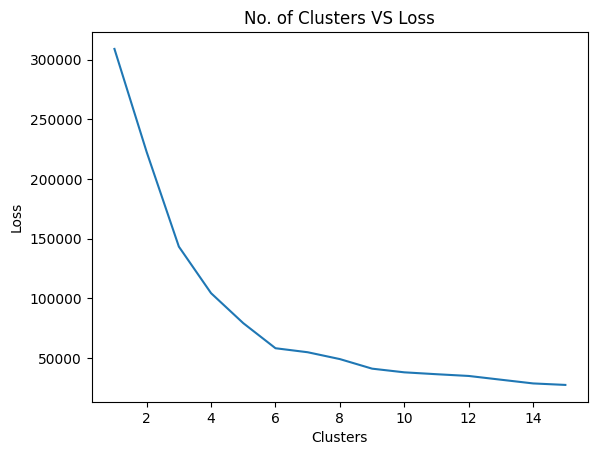

In [40]:
X = pd.concat([df['Gender'].replace({'Male': 1, 'Female': 0}), df.iloc[:, 2:]], axis=1)

wcss = []

for i in range(1, 16):
  km = KMeans(n_clusters=i)
  km.fit(X)
  wcss.append(km.inertia_)

sns.lineplot(x=list(range(1, 16)), y=wcss)
plt.xlabel("Clusters")
plt.ylabel("Loss")
plt.title("No. of Clusters VS Loss")
plt.show()

## 📌 Step 40. Apply KMeans with 6 Clusters

- Use `random_state=0` for reproducibility.
- Store cluster centers in `clusters`.

In [41]:
km = KMeans(n_clusters=6, random_state=0)

pred = km.fit_predict(X)

clusters = km.cluster_centers_
print(max(pred))

5


## 📌 Step 41. Evaluate Clustering (Any Clustering Algorithm)

- Calculates **Silhouette Score** and **Davies-Bouldin Score** using predicted clusters.

In [42]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f"Silhouette Score: {silhouette_score(X, pred)}")
print(f'Davies-Bouldin Score: {davies_bouldin_score(X, pred)}')

Silhouette Score: 0.4506609653808789
Davies-Bouldin Score: 0.752090283485522


## 📌 Step 42. K-Distance Plot for DBSCAN Epsilon Estimation

- Helps estimate optimal `eps` value for DBSCAN using the elbow method.
- Uses 6th nearest neighbor distance.

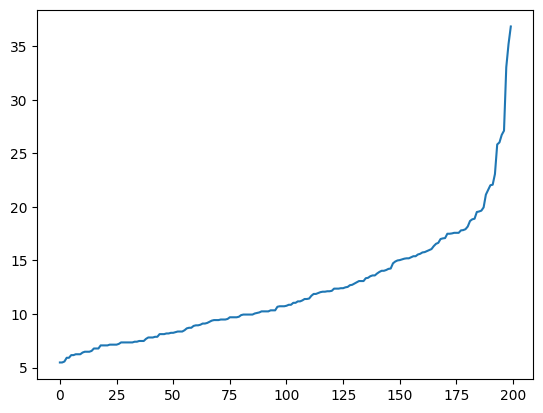

In [43]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

nearest_nei = NearestNeighbors(n_neighbors=6)

nearest_nei.fit(X)
knn, _ = nearest_nei.kneighbors(X)

sorted_knn = np.sort(knn[:, -1])

plt.plot(sorted_knn)
plt.show()

## 📌 Step 43. Apply DBSCAN with eps = 7

- `eps=7` empirically works for this dataset (trial & error).
- `min_samples=5` ensures each cluster has at least 5 core points.

In [45]:
dbs = DBSCAN(eps=7, min_samples=5)
# No idea why epsilon value of 7 works here

pred = dbs.fit_predict(X)

## 📌 Step 44. Evaluate DBSCAN (Excluding Noise)

- Excludes noise (`pred == -1`) when evaluating clustering metrics.

In [46]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f"Silhouette Score: {silhouette_score(X[pred != -1], pred[pred != -1])}")
print(f'Davies-Bouldin Score: {davies_bouldin_score(X[pred != -1], pred[pred != -1])}')

Silhouette Score: 0.5435939356800156
Davies-Bouldin Score: 0.5916017180682446


## 📌 Step 45. Apply Agglomerative Clustering with 6 Clusters

- Uses the `AgglomerativeClustering` method to form 6 hierarchical clusters.

In [47]:
agg = AgglomerativeClustering(n_clusters=6)

pred = agg.fit_predict(X)
print(max(pred))

5


## 📌 Step 46. Evaluate Agglomerative Clustering

- Use clustering metrics on the predicted labels from hierarchical clustering.

In [48]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(f"Silhouette Score: {silhouette_score(X, pred)}")
print(f'Davies-Bouldin Score: {davies_bouldin_score(X, pred)}')

Silhouette Score: 0.4428008535928764
Davies-Bouldin Score: 0.7690392732314951
